## Assignment of Nuclei to Connexin Plaques

- tbd: figure out distances between nuclei (Typical in micrometers)
- figure out how far away connexin can be from the edge

1. Edge Finding between Nuclei: Make Delaunay Triangulation between Nuclei Center ( adjust spacing )
2. Matching connexin regions with closest edge: On the connection points check for closest connexin regions and return a table with connexin regions mapped to 2 nuclei

In [12]:
# load packages 
from pathlib import Path
BASE_DIR = Path.cwd().parent
RESULTS_DIR = BASE_DIR / 'results' / 'connect_nuclei_with_cnx'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
# import stackview
from skimage import io
# import numpy as np
# import matplotlib.pyplot as plt
import sys
sys.path.append(str(BASE_DIR / 'src'))
# python files
# from cellpose import io
import pandas as pd
from nuclei_assignment import build_nuclei_edges, match_connexin_to_nuclei_pairs
# import numpy as np
# from skimage.measure import regionprops_table

DISP_VMIN = 0           # constant grayscale display range, fixed across ALL planes so that
DISP_VMAX = 10000       # depth comparisons are visually consistent (tune to taste)



In [13]:
# load the locations of connexin labelled regions and nuclei centers 

# connexin data 
mask_labelled_connexin_regions = io.imread(BASE_DIR / 'data/localization_binary_masks/brightest_region_label_mask.tiff')
df_region_properties = pd.read_csv(BASE_DIR / 'data/localization_binary_masks/region_properties.csv')
binary_sauvola_21_stack = io.imread(BASE_DIR / 'data/segmented/binary_sauvola3d_w9_21_21_k0_15.tiff')
# troponin_stack = io.imread(BASE_DIR / 'data/corrected_images/cTnT.tif')

# nuclei data 
df_center_nuclei = pd.read_csv(BASE_DIR / 'data/raw/nuclei_dataset/corrected_nuclei_center.csv') #-> the original has false measurements create new order should be: [z,y,x]
mask_nuclei = io.imread(BASE_DIR / 'data/raw/nuclei_dataset/nuclei_1_raw_Object Identities_test-exported_data_Input.tiff')
mask_nuclei = mask_nuclei[:, 15:, :]  # file was already cropped in z (441 planes) and x (976 px) to the connexin frame before export; here we only trim the top 15 y-pixels

# connexin preprocessed 
preprocessed_image = io.imread(BASE_DIR / 'data/preprocessed/background_removed_and_deconvolved_img.tiff')
preprocessed_image= preprocessed_image[60:501, :, 23:999] 

In [14]:
df_region_properties.head()

,label,z,y,x,area_voxels,volume_um3,mean_intensity
0,1,11.000000,1864.000000,594.000000,1.0,0.080909,5450.222656
1,2,31.824173,1864.802295,593.042956,3748.0,303.245995,7475.607422
2,3,18.000000,1857.000000,600.000000,1.0,0.080909,6017.766602
3,4,30.846816,1878.362134,612.542857,2905.0,235.039919,7375.608398
4,5,18.000000,1870.000000,615.000000,1.0,0.080909,5779.756836


In [4]:
# check shapes 
mask_nuclei.shape

(441, 2033, 976)

In [5]:
mask_labelled_connexin_regions.shape

(441, 2033, 976)

In [15]:
df_center_nuclei.head()

,label,z,y,x
0,1,46.860849,1886.072649,576.257285
1,2,54.365134,2021.402638,531.708976
2,3,39.833580,1836.513033,569.696291
3,4,52.768671,1912.819392,471.188606
4,5,36.279758,1841.630431,618.617047


### Create new Nuclei Center df from mask nuclei (because of 15px crop in y and 3 in x axes on cnx images)

In [6]:
# df_center_nuclei = get_nuclei_centerpoints(mask_nuclei)

Found 639 connected components


In [7]:
# save the new nuclei centerpoints
# df_center_nuclei.to_csv(BASE_DIR / 'data/raw/nuclei_dataset/corrected_nuclei_center.csv', index=False)

#### Plot the Nuclei binary mask together with connexin

/tmp/ipykernel_6908/764291428.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Blues')


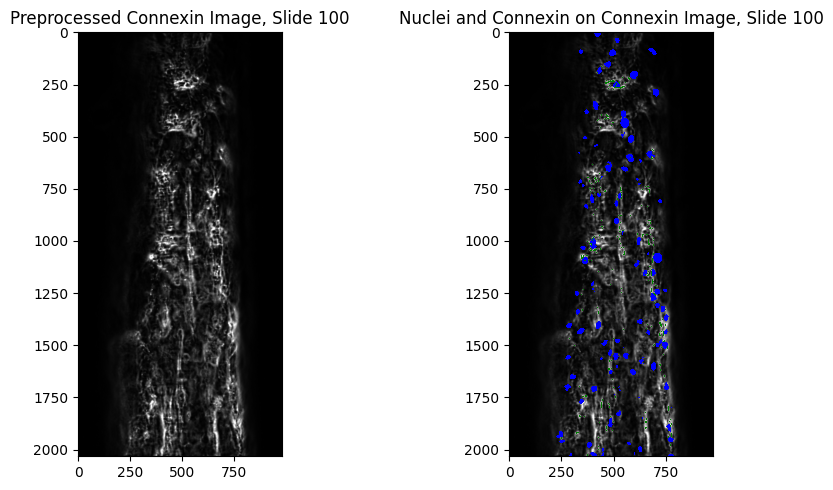

In [16]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

plane = 100

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# fig.suptitle('Nuclei and Connexin', fontsize=16, y=1.01)

ax[0].imshow(preprocessed_image[plane], cmap='gray', vmin=DISP_VMIN, vmax=DISP_VMAX)
ax[0].set_title(f"Preprocessed Connexin Image, Slide {plane}")

ax[1].imshow(preprocessed_image[plane, :, :], cmap='gray', vmin=DISP_VMIN, vmax=DISP_VMAX)

# Make background (0) transparent, nuclei visible
cmap = plt.cm.get_cmap('Blues')
colors = cmap(np.arange(cmap.N))
colors[0, -1] = 0  # set alpha=0 only for the 0 value (background)
transparent_cmap = mcolors.ListedColormap(colors)

ax[1].imshow(mask_nuclei[plane, :, :], cmap=mcolors.ListedColormap(['none', 'blue']), interpolation='none')
ax[1].imshow(mask_labelled_connexin_regions[plane, :, :], cmap=mcolors.ListedColormap(['none', 'green']), interpolation='none')
ax[1].set_title(f"Nuclei and Connexin on Connexin Image, Slide {plane}")

# ax[1].contour(mask_nuclei[(150+69), 500:1250, :], [0.5], linewidths=1.3, colors='b')
# ax[1].contour(mask_connexin_regions[0, 500:1250, :], [0.5], linewidths=0.5, colors='r')

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'nuclei_connexin_overlay_plane.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualize in Napari

In [8]:
# visualize just the preprocessed connexin in napari
import napari
from napari_animation import Animation

viewer = napari.Viewer()
viewer.add_image(cnx, name='Connexin', opacity=1)
viewer.add_image(mask_nuclei[(150+69):(150+69+10)].astype(bool), name='Nuclei')
viewer.add_image(binary_sauvola_21_stack.astype(int) > 0 , name='Connexin Segmented Areas', colormap='green', opacity = 0.5)

# # Show the orientation axes box (XYZ indicator)
viewer.axes.visible = True
viewer.axes.colored = True   # X=red, Y=green, Z=blue
viewer.axes.dashed = False   # solid lines
viewer.axes.labels = True    # show X, Y, Z labels

# viewer.close()

ModuleNotFoundError: No module named 'napari'

### Match Connexin to nuclei pairs

In [18]:
# use this when you have full stack 

edges, nuclei_coords_um = build_nuclei_edges(
    nuclei_coords=df_center_nuclei[['z', 'y', 'x']].values,
    spacing=(0.766, 0.325, 0.325),
    max_edge_distance= 140    # micrometers, tune to your typical inter-nucleus spacing
)

# connexin regions: locations table needs columns ['z', 'y', 'x'] (voxel centroids)
print(df_region_properties.columns.tolist())
locations = df_region_properties  # rename here only if the column names differ

matched = match_connexin_to_nuclei_pairs(
    locations, edges, nuclei_coords_um,
    spacing=(0.766, 0.325, 0.325),
    distance_threshold=12     # micrometers, tune to expected junction-to-line distance
)

matched.head()

  Nuclei: 639
  Candidate neighbor pairs found: 4653
  Kept after distance filter: 4497
['label', 'z', 'y', 'x', 'area_voxels', 'volume_um3', 'mean_intensity']
  Connexin regions assigned to a nuclei pair: 20372 / 20985


,label,z,y,x,area_voxels,volume_um3,mean_intensity,nucleus_1,nucleus_2,nucleus_distance_um,region_to_line_um
0,1,11.000000,1864.000000,594.000000,1.0,0.080909,5450.222656,NaN,NaN,NaN,20.839494
1,2,31.824173,1864.802295,593.042956,3748.0,303.245995,7475.607422,4.0,20.0,91.856193,5.205981
2,3,18.000000,1857.000000,600.000000,1.0,0.080909,6017.766602,NaN,NaN,NaN,15.089355
3,4,30.846816,1878.362134,612.542857,2905.0,235.039919,7375.608398,1.0,4.0,66.357345,7.338041
4,5,18.000000,1870.000000,615.000000,1.0,0.080909,5779.756836,NaN,NaN,NaN,15.812064


### Vizualization of Results

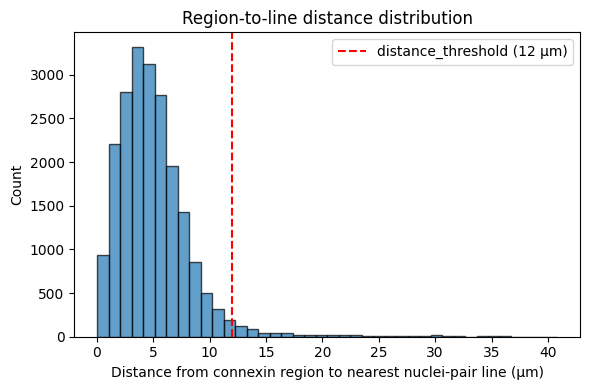

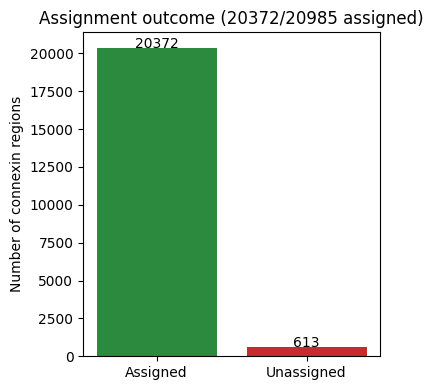

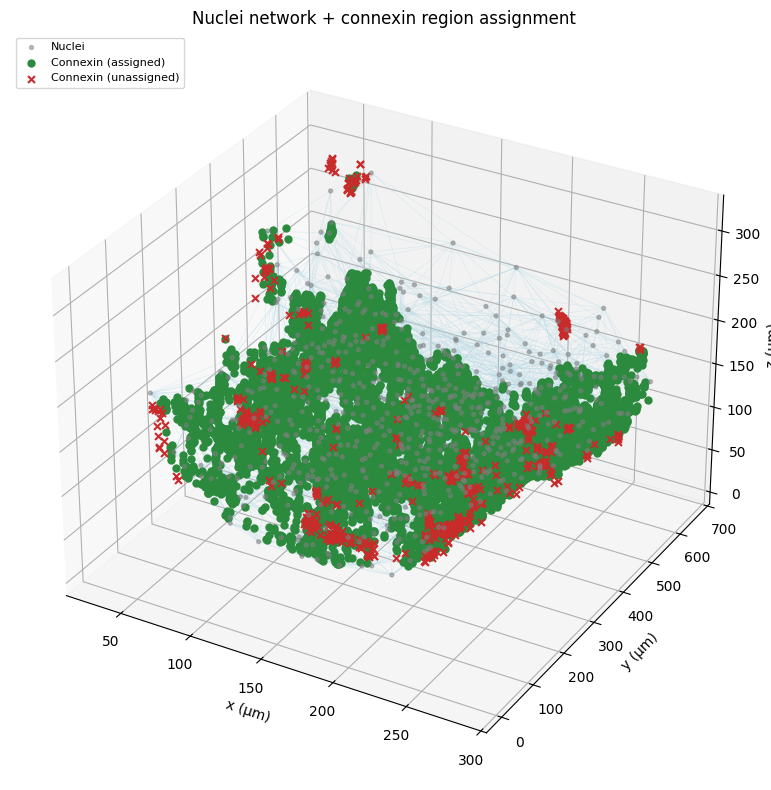

/tmp/ipykernel_6908/3624113315.py:99: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_6908/3624113315.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(RESULTS_DIR / 'assignment_topdown_xy.png', dpi=150, bbox_inches='tight')


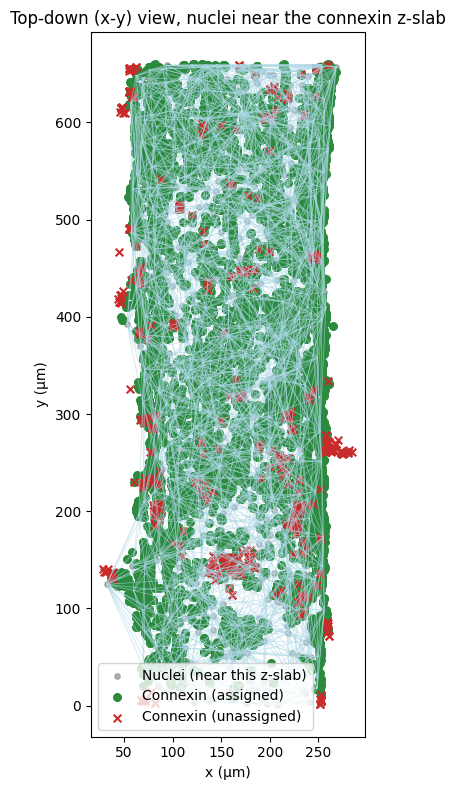

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401, needed for 3d projection

# ============================================================
# 1. Distribution of region-to-line distances (calibration check)
# ============================================================
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(matched['region_to_line_um'].dropna(), bins=40, edgecolor='black', alpha=0.7)
ax.axvline(12.0, color='red', linestyle='--', label='distance_threshold (12 µm)')
ax.set_xlabel('Distance from connexin region to nearest nuclei-pair line (µm)')
ax.set_ylabel('Count')
ax.set_title('Region-to-line distance distribution')
ax.legend()
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'region_to_line_distance_hist.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 2. Assigned vs unassigned connexin regions
# ============================================================
n_assigned = matched['nucleus_1'].notna().sum()
n_unassigned = matched['nucleus_1'].isna().sum()

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(['Assigned', 'Unassigned'], [n_assigned, n_unassigned], color=['#2b8a3e', '#c92a2a'])
ax.set_ylabel('Number of connexin regions')
ax.set_title(f'Assignment outcome ({n_assigned}/{len(matched)} assigned)')
for i, v in enumerate([n_assigned, n_unassigned]):
    ax.text(i, v + 1, str(v), ha='center')
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'assignment_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 3. 3D scatter: nuclei, Delaunay edges, connexin regions (colored by assignment)
# ============================================================
fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection='3d')

# nuclei as small grey dots
ax.scatter(nuclei_coords_um[:, 2], nuclei_coords_um[:, 1], nuclei_coords_um[:, 0],
           s=8, c='grey', alpha=0.5, label='Nuclei')

# Delaunay edges (kept ones) as thin lines
for _, row in edges.iterrows():
    p1 = nuclei_coords_um[int(row['nucleus_1'])]
    p2 = nuclei_coords_um[int(row['nucleus_2'])]
    ax.plot([p1[2], p2[2]], [p1[1], p2[1]], [p1[0], p2[0]],
            color='lightblue', linewidth=0.4, alpha=0.4)

# connexin regions in cropped-frame coordinates, colored by assignment
locations_aligned_um = df_region_properties[['z', 'y', 'x']].to_numpy() * np.array([0.766, 0.325, 0.325])
assigned_mask = matched['nucleus_1'].notna().to_numpy()

ax.scatter(locations_aligned_um[assigned_mask, 2], locations_aligned_um[assigned_mask, 1],
           locations_aligned_um[assigned_mask, 0],
           s=25, c='#2b8a3e', label='Connexin (assigned)', depthshade=False)
ax.scatter(locations_aligned_um[~assigned_mask, 2], locations_aligned_um[~assigned_mask, 1],
           locations_aligned_um[~assigned_mask, 0],
           s=25, c='#c92a2a', marker='x', label='Connexin (unassigned)', depthshade=False)

ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_zlabel('z (µm)')
ax.set_title('Nuclei network + connexin region assignment')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'assignment_3d_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 4. Zoomed 2D top-down view (x-y) -- easier to read than the full 3D scatter
#    (nuclei filtered to the connexin z-range)
# ============================================================
z_lo, z_hi = locations_aligned_um[:, 0].min() - 10, locations_aligned_um[:, 0].max() + 10
nearby_nuclei = (nuclei_coords_um[:, 0] >= z_lo) & (nuclei_coords_um[:, 0] <= z_hi)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(nuclei_coords_um[nearby_nuclei, 2], nuclei_coords_um[nearby_nuclei, 1],
           s=15, c='grey', alpha=0.6, label='Nuclei (near this z-slab)')

for _, row in edges.iterrows():
    n1, n2 = int(row['nucleus_1']), int(row['nucleus_2'])
    if nearby_nuclei[n1] and nearby_nuclei[n2]:
        p1, p2 = nuclei_coords_um[n1], nuclei_coords_um[n2]
        ax.plot([p1[2], p2[2]], [p1[1], p2[1]], color='lightblue', linewidth=0.6, alpha=0.6)

ax.scatter(locations_aligned_um[assigned_mask, 2], locations_aligned_um[assigned_mask, 1],
           s=30, c='#2b8a3e', label='Connexin (assigned)')
ax.scatter(locations_aligned_um[~assigned_mask, 2], locations_aligned_um[~assigned_mask, 1],
           s=30, c='#c92a2a', marker='x', label='Connexin (unassigned)')

ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_title('Top-down (x-y) view, nuclei near the connexin z-slab')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'assignment_topdown_xy.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# visualization with voronoi 
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import Voronoi, voronoi_plot_2d

# ============================================================
# 4. Zoomed 2D top-down view (x-y) with Voronoi cell borders
#    -- Voronoi is the dual of Delaunay: cells here approximate
#       the physical borders between adjacent nuclei/cells
# ============================================================
z_lo, z_hi = locations_aligned_um[:, 0].min() - 10, locations_aligned_um[:, 0].max() + 10
nearby_nuclei = (nuclei_coords_um[:, 0] >= z_lo) & (nuclei_coords_um[:, 0] <= z_hi)

# 2D top-down nuclei positions (x, y) for the Voronoi diagram
nuclei_xy_nearby = nuclei_coords_um[nearby_nuclei][:, [2, 1]]  # columns: x, y

fig, ax = plt.subplots(figsize=(9, 9))

# --- Voronoi cell borders ---
if len(nuclei_xy_nearby) >= 4:  # scipy needs at least 4 points for a 2D Voronoi
    vor = Voronoi(nuclei_xy_nearby)
    voronoi_plot_2d(
        vor, ax=ax,
        show_points=False,       # we plot nuclei ourselves below
        show_vertices=False,
        line_colors='darkorange',
        line_width=1.0,
        line_alpha=0.6,
        point_size=0
    )
else:
    print("Not enough nearby nuclei for a Voronoi diagram (need >= 4)")

# --- nuclei ---
ax.scatter(nuclei_xy_nearby[:, 0], nuclei_xy_nearby[:, 1],
           s=15, c='grey', alpha=0.6, zorder=3, label='Nuclei (near this z-slab)')

# --- Delaunay edges (kept for reference / comparison with Voronoi borders) ---
for _, row in edges.iterrows():
    n1, n2 = int(row['nucleus_1']), int(row['nucleus_2'])
    if nearby_nuclei[n1] and nearby_nuclei[n2]:
        p1, p2 = nuclei_coords_um[n1], nuclei_coords_um[n2]
        ax.plot([p1[2], p2[2]], [p1[1], p2[1]],
                color='lightblue', linewidth=0.6, alpha=0.5, zorder=2)

# --- connexin regions ---
ax.scatter(locations_aligned_um[assigned_mask, 2], locations_aligned_um[assigned_mask, 1],
           s=30, c='#2b8a3e', label='Connexin (assigned)', zorder=4)
ax.scatter(locations_aligned_um[~assigned_mask, 2], locations_aligned_um[~assigned_mask, 1],
           s=30, c='#c92a2a', marker='x', label='Connexin (unassigned)', zorder=4)

# --- crop view to the actual data extent, since Voronoi edges run to infinity ---
pad = 15  # µm
x_min, x_max = nuclei_xy_nearby[:, 0].min() - pad, nuclei_xy_nearby[:, 0].max() + pad
y_min, y_max = nuclei_xy_nearby[:, 1].min() - pad, nuclei_xy_nearby[:, 1].max() + pad
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_title('Top-down (x-y) view: Voronoi cell borders + Delaunay graph + connexin assignment')
ax.legend(fontsize=8)
ax.set_aspect('equal')
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'assignment_voronoi_topdown.png', dpi=150, bbox_inches='tight')
plt.show()

### Shows everything as a big messy mesh 

In [11]:
import numpy as np
import pandas as pd
from scipy.spatial import Voronoi, ConvexHull
import napari


def build_voronoi_mesh(nuclei_coords_um, max_region_extent=100.0):
    """
    Build a combined triangle mesh of 3D Voronoi cells around each nucleus,
    suitable for a single napari surface layer.

    Unbounded regions (nuclei on the outer boundary of the point cloud, whose
    Voronoi cell extends to infinity) are skipped -- they have no finite
    volume to draw without artificial clipping.

    Parameters
    ----------
    nuclei_coords_um : (N, 3) array, order (z, y, x), in micrometers.
    max_region_extent : float
        Sanity-check cutoff (µm). A finite region whose vertices span more
        than this from its nucleus center is treated as a numerically-finite-
        but-unreasonably-large sliver (common near the point cloud's edge)
        and skipped rather than drawn as a giant distorted cell.

    Returns
    -------
    vertices : (V, 3) array of all mesh vertices, concatenated across cells.
    faces    : (F, 3) array of triangle vertex indices into `vertices`.
    values   : (V,) array, one value per vertex (= source nucleus index),
               used to color each cell distinctly via a colormap.
    n_cells_drawn : int, how many nuclei got a finite drawable cell.
    """
    vor = Voronoi(nuclei_coords_um)

    all_vertices, all_faces, all_values = [], [], []
    vertex_offset = 0
    n_cells_drawn = 0

    for nucleus_idx, region_idx in enumerate(vor.point_region):
        region = vor.regions[region_idx]

        # skip empty or unbounded regions (contain vertex index -1)
        if len(region) == 0 or -1 in region:
            continue

        region_vertices = vor.vertices[region]

        # skip degenerate huge regions (numerically finite but unreasonable)
        center = nuclei_coords_um[nucleus_idx]
        if np.linalg.norm(region_vertices - center, axis=1).max() > max_region_extent:
            continue

        # need at least 4 non-coplanar points for a 3D convex hull
        if len(region_vertices) < 4:
            continue

        try:
            hull = ConvexHull(region_vertices)
        except Exception:
            # coplanar / degenerate point set -- can't form a 3D hull
            continue

        all_vertices.append(region_vertices)
        all_faces.append(hull.simplices + vertex_offset)
        all_values.append(np.full(len(region_vertices), nucleus_idx))

        vertex_offset += len(region_vertices)
        n_cells_drawn += 1

    vertices = np.vstack(all_vertices)
    faces = np.vstack(all_faces)
    values = np.concatenate(all_values)

    print(f"Voronoi mesh: {n_cells_drawn} / {len(nuclei_coords_um)} nuclei "
          f"have a finite, drawable cell")

    return vertices, faces, values, n_cells_drawn


# ------------------------------------------------------------------ #
# Build the Voronoi mesh from nuclei centers (µm, z-y-x order)
# ------------------------------------------------------------------ #
vor_vertices, vor_faces, vor_values, n_drawn = build_voronoi_mesh(nuclei_coords_um)

# ------------------------------------------------------------------ #
# Delaunay edges as napari vectors (start point + direction vector)
# ------------------------------------------------------------------ #
edge_starts = nuclei_coords_um[edges['nucleus_1'].to_numpy()]
edge_ends   = nuclei_coords_um[edges['nucleus_2'].to_numpy()]
edge_vectors = np.stack([edge_starts, edge_ends - edge_starts], axis=1)  # (n_edges, 2, 3)

# ------------------------------------------------------------------ #
# Connexin points, split by assignment (from the `matched` table)
# ------------------------------------------------------------------ #
assigned_mask = matched['nucleus_1'].notna().to_numpy()
connexin_assigned_um   = locations_aligned_um[assigned_mask]
connexin_unassigned_um = locations_aligned_um[~assigned_mask]

# ------------------------------------------------------------------ #
# Napari viewer
# ------------------------------------------------------------------ #
viewer = napari.Viewer(ndisplay=3)

viewer.add_points(
    nuclei_coords_um,
    name='Nuclei',
    size=6,
    face_color='grey',
    opacity=0.9,
)

viewer.add_surface(
    (vor_vertices, vor_faces, vor_values),
    name='Voronoi cells',
    colormap='hsv',      # distinct-ish color per cell
    opacity=0.25,         # see-through
    shading='smooth',
)

viewer.add_vectors(
    edge_vectors,
    name='Delaunay edges',
    edge_color='lightblue',
    edge_width=0.4,
    opacity=0.6,
)

viewer.add_points(
    connexin_assigned_um,
    name='Connexin (assigned)',
    size=4,
    face_color='green',
    opacity=1.0,
)

viewer.add_points(
    connexin_unassigned_um,
    name='Connexin (unassigned)',
    size=4,
    face_color='red',
    symbol='x',
    opacity=1.0,
)

viewer.axes.visible = True
viewer.axes.colored = True
viewer.axes.dashed = False
viewer.axes.labels = True

napari.run()

ModuleNotFoundError: No module named 'napari'

### Shows only important cells 

In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial import Voronoi, ConvexHull, cKDTree
import napari


def build_voronoi_mesh_for_subset(nuclei_coords_um, nucleus_indices, max_region_extent=100.0):
    """Computes Voronoi on the FULL point set for correct cell shapes,
    but only builds mesh geometry for the given subset."""
    vor = Voronoi(nuclei_coords_um)

    all_vertices, all_faces, all_values = [], [], []
    vertex_offset = 0
    drawn_indices = []

    for nucleus_idx in nucleus_indices:
        region_idx = vor.point_region[nucleus_idx]
        region = vor.regions[region_idx]

        if len(region) == 0 or -1 in region:
            continue  # unbounded cell -- nucleus 504 or a neighbor sits on the outer hull
        region_vertices = vor.vertices[region]
        center = nuclei_coords_um[nucleus_idx]
        if np.linalg.norm(region_vertices - center, axis=1).max() > max_region_extent:
            continue
        if len(region_vertices) < 4:
            continue
        try:
            hull = ConvexHull(region_vertices)
        except Exception:
            continue

        all_vertices.append(region_vertices)
        all_faces.append(hull.simplices + vertex_offset)
        all_values.append(np.full(len(region_vertices), nucleus_idx))
        vertex_offset += len(region_vertices)
        drawn_indices.append(nucleus_idx)

    if len(all_vertices) == 0:
        return None, None, None, drawn_indices

    vertices = np.vstack(all_vertices)
    faces = np.vstack(all_faces)
    values = np.concatenate(all_values)
    return vertices, faces, values, drawn_indices


# ------------------------------------------------------------------ #
# Step 1 -- fixed seed nucleus + its 8 nearest neighbors
# ------------------------------------------------------------------ #
seed_nucleus_idx = 504
n_neighbors = 1

assigned_mask = matched['nucleus_1'].notna().to_numpy()

tree = cKDTree(nuclei_coords_um)
_, neighbor_idx = tree.query(nuclei_coords_um[seed_nucleus_idx], k=n_neighbors + 1)  # +1 includes itself
local_nucleus_indices = neighbor_idx
local_nuclei_set = set(local_nucleus_indices.tolist())

print(f"Seed nucleus: {seed_nucleus_idx}")
print(f"Local neighborhood: {len(local_nucleus_indices)} nuclei "
      f"(indices: {sorted(local_nuclei_set)})")

# ------------------------------------------------------------------ #
# Step 2 -- Voronoi mesh, restricted to this local neighborhood
# ------------------------------------------------------------------ #
vor_vertices, vor_faces, vor_values, drawn_indices = build_voronoi_mesh_for_subset(
    nuclei_coords_um, local_nucleus_indices
)
print(f"Drawable (finite) cells in this neighborhood: {len(drawn_indices)} / {len(local_nucleus_indices)}")

# ------------------------------------------------------------------ #
# Step 3 -- Delaunay edges where BOTH endpoints are in the local set
# ------------------------------------------------------------------ #
local_edges_mask = edges['nucleus_1'].isin(local_nuclei_set) & edges['nucleus_2'].isin(local_nuclei_set)
local_edges = edges[local_edges_mask]

edge_starts = nuclei_coords_um[local_edges['nucleus_1'].to_numpy()]
edge_ends   = nuclei_coords_um[local_edges['nucleus_2'].to_numpy()]
edge_vectors = np.stack([edge_starts, edge_ends - edge_starts], axis=1)

print(f"Delaunay edges within neighborhood: {len(local_edges)}")

# ------------------------------------------------------------------ #
# Step 4 -- connexin points (both types) within this neighborhood
# ------------------------------------------------------------------ #
local_coords = nuclei_coords_um[local_nucleus_indices]

# assigned connexin: filter by matched nucleus_1/nucleus_2 membership (works fine here)
assigned_in_nbhd = assigned_mask & (
    matched['nucleus_1'].isin(local_nuclei_set) | matched['nucleus_2'].isin(local_nuclei_set)
)
connexin_assigned_local = locations_aligned_um[assigned_in_nbhd]

# unassigned connexin: nucleus_1/nucleus_2 are always NaN for these rows, so
# membership filtering can never work -- use spatial distance to the local
# nuclei cluster instead (e.g. within some radius of the crop's centroid)
radius_um = np.linalg.norm(local_coords - local_coords.mean(axis=0), axis=1).max() + 10  # µm padding
dist_to_crop_center = np.linalg.norm(locations_aligned_um - local_coords.mean(axis=0), axis=1)
unassigned_in_nbhd = (~assigned_mask) & (dist_to_crop_center <= radius_um)
connexin_unassigned_local = locations_aligned_um[unassigned_in_nbhd]

print(f"Connexin in neighborhood: assigned={len(connexin_assigned_local)}, "
      f"unassigned={len(connexin_unassigned_local)}")

# ------------------------------------------------------------------ #
# Step 5 -- napari viewer
# ------------------------------------------------------------------ #
viewer = napari.Viewer(ndisplay=3)

viewer.add_points(
    nuclei_coords_um[local_nucleus_indices],
    name='Nuclei (local)',
    size=6,
    face_color='grey',
    opacity=0.9,
)

if vor_vertices is not None:
    viewer.add_surface(
        (vor_vertices, vor_faces, vor_values),
        name='Voronoi cells (local)',
        colormap='hsv',
        opacity=0.25,
        shading='smooth',
    )

if len(local_edges) > 0:
    viewer.add_vectors(
        edge_vectors,
        name='Delaunay edges (local)',
        edge_color='lightblue',
        edge_width=0.4,
        opacity=0.6,
    )

if len(connexin_assigned_local) > 0:
    viewer.add_points(
        connexin_assigned_local,
        name='Connexin (assigned)',
        size=4,
        face_color='green',
        opacity=1.0,
        blending='translucent_no_depth',
    )

if len(connexin_unassigned_local) > 0:
    viewer.add_points(
        connexin_unassigned_local,
        name='Connexin (unassigned)',
        size=4,
        face_color='red',
        symbol='x',
        opacity=1.0,
        blending='translucent_no_depth',
    )

local_coords = nuclei_coords_um[local_nucleus_indices]
viewer.camera.center = local_coords.mean(axis=0)

viewer.axes.visible = True
viewer.axes.colored = True
viewer.axes.dashed = False
viewer.axes.labels = True

napari.run()

### Result Analysis

Edge length statistics (normalized coords):
  Min    : 10.6 µm
  Mean   : 52.3 µm
  Std    : 49.6 µm
  Max    : 633.3 µm
  Auto threshold: 151.5 µm

Expected adjacent nucleus distance: 10–40 µm
Auto threshold looks correct


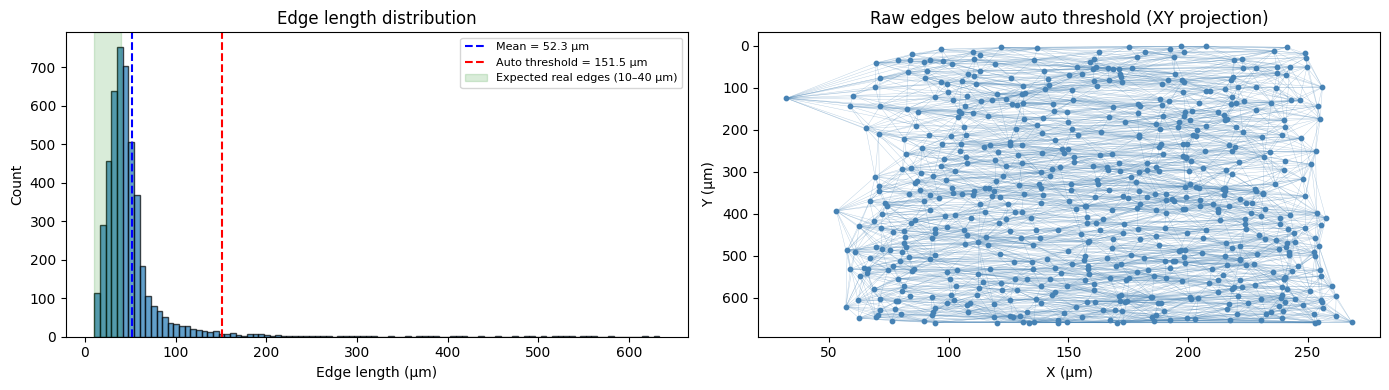

In [22]:
from scipy.spatial import Delaunay
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt

# use normalized coords
tri = Delaunay(nuclei_coords_um)
edges_set = set()
for simplex in tri.simplices:
    for i, j in combinations(simplex, 2):
        edges_set.add((min(i, j), max(i, j)))

all_lengths = np.array([
    np.linalg.norm(nuclei_coords_um[i] - nuclei_coords_um[j])
    for i, j in edges_set
])

auto_threshold = all_lengths.mean() + 2 * all_lengths.std()

print(f"Edge length statistics (normalized coords):")
print(f"  Min    : {all_lengths.min():.1f} µm")
print(f"  Mean   : {all_lengths.mean():.1f} µm")
print(f"  Std    : {all_lengths.std():.1f} µm")
print(f"  Max    : {all_lengths.max():.1f} µm")
print(f"  Auto threshold: {auto_threshold:.1f} µm")

# expected cardiomyocyte nucleus spacing
expected_min = 10   # µm — minimum nucleus-nucleus distance
expected_max = 40   # µm — maximum for adjacent cells

print(f"\nExpected adjacent nucleus distance: {expected_min}–{expected_max} µm")
print(f"Auto threshold {'looks correct' if expected_min < auto_threshold < 200 else 'may need manual adjustment'}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# histogram
axes[0].hist(all_lengths, bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(all_lengths.mean(), color='blue', linestyle='--',
                label=f'Mean = {all_lengths.mean():.1f} µm')
axes[0].axvline(auto_threshold, color='red', linestyle='--',
                label=f'Auto threshold = {auto_threshold:.1f} µm')
axes[0].axvspan(expected_min, expected_max, alpha=0.15, color='green',
                label=f'Expected real edges ({expected_min}–{expected_max} µm)')
axes[0].set_xlabel('Edge length (µm)')
axes[0].set_ylabel('Count')
axes[0].set_title('Edge length distribution')
axes[0].legend(fontsize=8)

# XY projection of ALL raw edges below threshold
axes[1].set_title('Raw edges below auto threshold (XY projection)')
for i, j in edges_set:
    if all_lengths[list(edges_set).index((i,j))] <= auto_threshold:
        n1 = nuclei_coords_um[i]
        n2 = nuclei_coords_um[j]
        axes[1].plot([n1[2], n2[2]], [n1[1], n2[1]],
                     'steelblue', linewidth=0.3, alpha=0.4)
axes[1].scatter(nuclei_coords_um[:, 2], nuclei_coords_um[:, 1],
                c='steelblue', s=10, zorder=3)
axes[1].set_xlabel('X (µm)')
axes[1].set_ylabel('Y (µm)')
axes[1].invert_yaxis()

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'delaunay_edge_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()